# Random Forest NPF Event Prediction

This notebook trains a Random Forest model to predict whether an NPF event happened on each day. Labels are mapped as `b` and `e` = event, `n` and `u` = non-event. The split is a random 9:1 train/checking split with stratification by event class and `random_state=42` for reproducibility.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
)
plt.rcParams.update({
    'font.family': 'Arial', 'font.size': 13,
    'axes.labelsize': 13, 'axes.titlesize': 13,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.linewidth': 1.5
})
plt.rcParams.update({"figure.dpi": 130})

_raw = [
    (37, 70, 159), (58, 90, 170), (78, 111, 183), (104, 144, 199),
    (131, 175, 212), (158, 207, 227), (187, 224, 234), (218, 240, 246),
    (254, 240, 202), (254, 223, 146), (252, 197, 122), (251, 169, 94),
    (245, 134, 78), (237, 98, 58), (221, 78, 46), (210, 58, 46),
]
CUSTOM_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "custom16", [(r / 255, g / 255, b / 255) for r, g, b in _raw], N=256
)
FEATURE_IMPORTANCE_COLOR = tuple(v / 255 for v in _raw[1])


C:\Users\rory\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load Merged Daily Data

In [2]:
project_root = Path.cwd()
if not (project_root / "processed" / "daily_merged_features_labels.csv").exists():
    project_root = project_root.parent

data_path = project_root / "processed" / "daily_merged_features_labels.csv"

figures_dir = project_root / "processed" / "model_figures"
figures_dir.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

preview_cols = [col for col in df.columns if "std" not in col.lower()]
display(df[preview_cols].head())

Rows: 303
Date range: 2023-01-18 to 2023-12-29


,date,average_UF_minus_FINE,max_UF_minus_FINE,min_UF_minus_FINE,p25_UF_minus_FINE,p50_UF_minus_FINE,p75_UF_minus_FINE,geometric_mean_daily_mean_nm,geometric_mean_smallest_25pct_daily_mean_nm,geometric_mean_smallest_50pct_daily_mean_nm,geometric_mean_smallest_75pct_daily_mean_nm,label_code,label_class,event_class,is_event
0,2023-01-18,134.897925,4350.229500,1.083008,21.678406,44.337402,113.006100,55.945575,24.531195,35.477993,47.113354,b,Class II,event,1
1,2023-01-19,238.332750,4285.049000,2.384216,23.180084,41.562165,133.379150,41.778434,17.783125,22.051792,32.509671,e,Class I,event,1
2,2023-01-20,295.914355,4789.889600,0.413330,145.406250,201.693850,283.112060,40.536519,32.322292,35.004340,37.584814,b,Class II,event,1
3,2023-01-21,75.895652,475.964360,0.437988,11.603089,27.659302,56.358337,66.185823,58.095361,61.634528,63.636255,n,nonevent,non_event,0
4,2023-01-22,16.770142,37.380005,2.987427,3.380493,14.313843,25.788940,79.823490,60.946514,63.393444,71.171555,n,nonevent,non_event,0


## Prepare Features and Target

All numeric daily parameters except `geometric_std` variables are used as model inputs. Date and label columns are excluded from `X`, and feature names are shortened for plotting.

In [3]:
target_col = "is_event"
exclude_cols = {"date", "label_code", "label_class", "event_class", target_col}
all_feature_cols = [col for col in df.columns if col not in exclude_cols]
dropped_std_cols = [col for col in all_feature_cols if "std" in col.lower()]
feature_cols = [col for col in all_feature_cols if col not in dropped_std_cols]

feature_name_map = {
    "average_UF_minus_FINE": "UF mean",
    "max_UF_minus_FINE": "UF max",
    "min_UF_minus_FINE": "UF min",
    "p25_UF_minus_FINE": "UF p25",
    "p50_UF_minus_FINE": "UF p50",
    "p75_UF_minus_FINE": "UF p75",
    "geometric_mean_daily_mean_nm": "GM mean",
    "geometric_mean_smallest_25pct_daily_mean_nm": "GM low25",
    "geometric_mean_smallest_50pct_daily_mean_nm": "GM low50",
    "geometric_mean_smallest_75pct_daily_mean_nm": "GM low75",
}

X = df[feature_cols].rename(columns=feature_name_map)
feature_cols = list(X.columns)
y = df[target_col].astype(int)

print(f"Feature count: {len(feature_cols)}")
print(feature_cols)
print("\nDropped std variables:")
print(dropped_std_cols)
print("\nTarget counts:")
print(y.value_counts().rename(index={0: "non_event", 1: "event"}))

Feature count: 10
['UF mean', 'UF max', 'UF min', 'UF p25', 'UF p50', 'UF p75', 'GM mean', 'GM low25', 'GM low50', 'GM low75']

Dropped std variables:
['geometric_std_daily_mean_nm', 'geometric_std_smallest_25pct_daily_mean_nm', 'geometric_std_smallest_50pct_daily_mean_nm', 'geometric_std_smallest_75pct_daily_mean_nm']

Target counts:
is_event
non_event    195
event        108
Name: count, dtype: int64


## Random Stratified 9:1 Split

In [4]:
X_train, X_check, y_train, y_check = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y,
)

check_dates = df.loc[X_check.index, "date"]

print(f"Training rows: {len(X_train)}")
print(f"Checking rows: {len(X_check)}")
print("Random state: 42")
print(f"Training date range: {df.loc[X_train.index, 'date'].min().date()} to {df.loc[X_train.index, 'date'].max().date()}")
print(f"Checking date range: {check_dates.min().date()} to {check_dates.max().date()}")
print()
print("Training target counts:")
print(y_train.value_counts().rename(index={0: "non_event", 1: "event"}))
print()
print("Checking target counts:")
print(y_check.value_counts().rename(index={0: "non_event", 1: "event"}))


Training rows: 272
Checking rows: 31
Random state: 42
Training date range: 2023-01-18 to 2023-12-27
Checking date range: 2023-01-19 to 2023-12-29

Training target counts:
is_event
non_event    175
event         97
Name: count, dtype: int64

Checking target counts:
is_event
non_event    20
event        11
Name: count, dtype: int64


## Train Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=2,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_check)
y_prob = rf.predict_proba(X_check)[:, 1]

print("Model trained.")

Model trained.


## Checking-Set Results

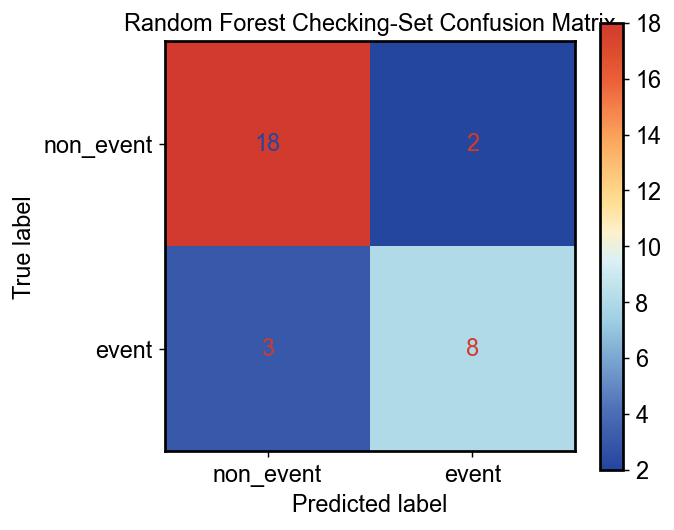

In [6]:
cm = confusion_matrix(y_check, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non_event", "event"])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp.plot(cmap=CUSTOM_CMAP, values_format="d", ax=ax, colorbar=True)
ax.set_title("Random Forest Checking-Set Confusion Matrix")
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


## ROC Curve

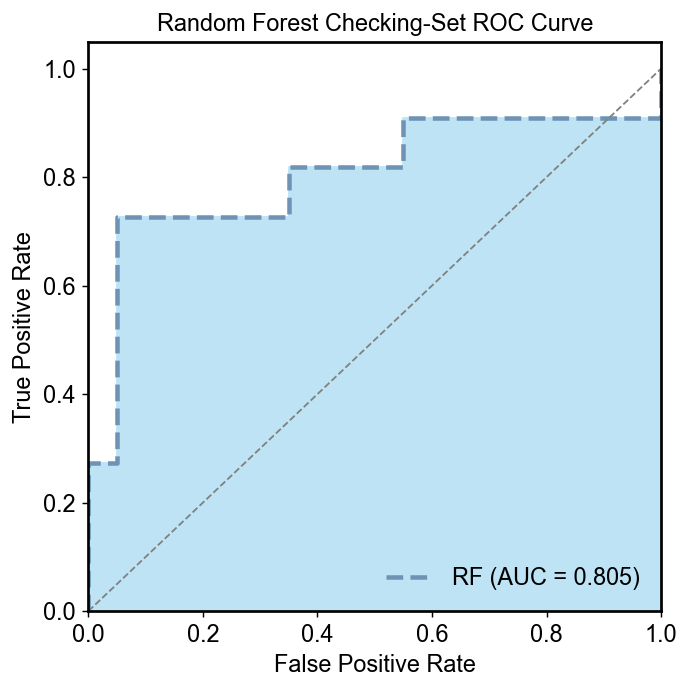

ROC AUC: 0.805


In [7]:
fpr, tpr, _ = roc_curve(y_check, y_prob)
roc_auc = roc_auc_score(y_check, y_prob)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.fill_between(fpr, tpr, 0, color="#BEE3F5", zorder=1)
ax.plot(fpr, tpr, color="#6E93B5", linestyle="--", linewidth=2.5, label=f"RF (AUC = {roc_auc:.3f})", zorder=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title("Random Forest Checking-Set ROC Curve")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig(figures_dir / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"ROC AUC: {roc_auc:.3f}")


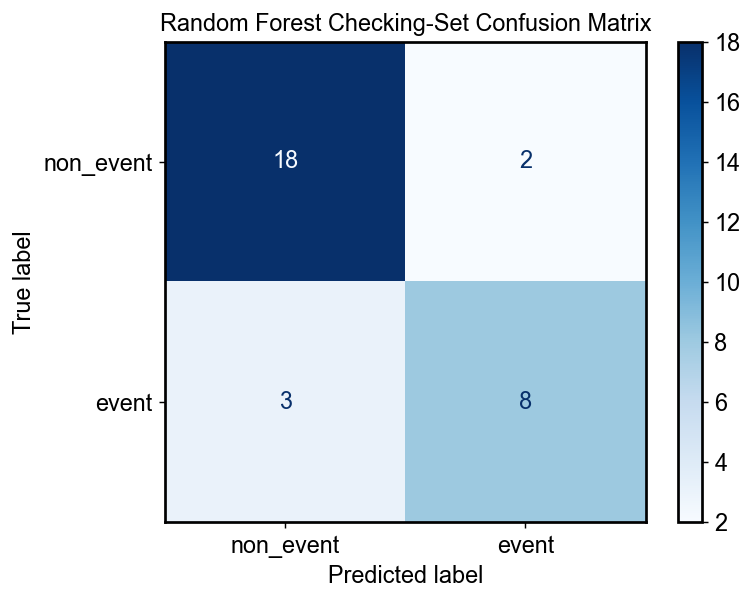

In [8]:
cm = confusion_matrix(y_check, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non_event", "event"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest Checking-Set Confusion Matrix")
plt.show()

## Checking-Set Predictions

In [9]:
predictions = pd.DataFrame({
    "date": check_dates.dt.strftime("%Y-%m-%d").to_numpy(),
    "label_code": df.loc[X_check.index, "label_code"].to_numpy(),
    "actual_is_event": y_check.to_numpy(),
    "predicted_is_event": y_pred,
    "predicted_event_probability": y_prob,
})
predictions["correct"] = predictions["actual_is_event"] == predictions["predicted_is_event"]
predictions = predictions.sort_values("date").reset_index(drop=True)
display(predictions)


,date,label_code,actual_is_event,predicted_is_event,predicted_event_probability,correct
0,2023-01-19,e,1,1,0.643110,True
1,2023-01-20,b,1,1,0.640223,True
2,2023-01-22,n,0,0,0.017126,True
3,2023-02-08,n,0,0,0.444683,True
4,2023-02-18,u,0,0,0.364834,True
5,2023-04-12,u,0,0,0.241842,True
6,2023-05-17,n,0,0,0.071788,True
7,2023-05-21,n,0,1,0.505267,False
8,2023-06-05,n,0,0,0.006574,True
9,2023-06-12,u,0,0,0.023941,True


## Feature Importance

,feature,importance
0,GM low25,0.209708
1,GM low50,0.148599
2,GM low75,0.123913
3,GM mean,0.111716
4,UF p75,0.107472
5,UF mean,0.076794
6,UF max,0.074861
7,UF p50,0.052098
8,UF p25,0.047539
9,UF min,0.047301


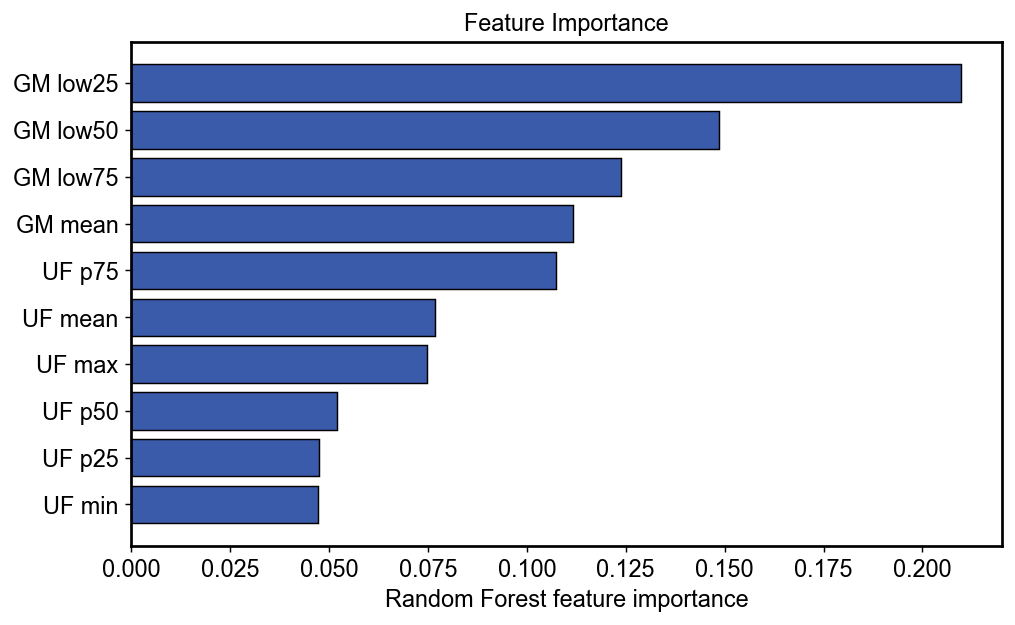

In [10]:
importance = (
    pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    importance["feature"][::-1],
    importance["importance"][::-1],
    color=FEATURE_IMPORTANCE_COLOR,
    edgecolor="black",
    linewidth=0.8,
)
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Feature Importance")
plt.tight_layout()
plt.savefig(figures_dir / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()


## SHAP Summary Plot

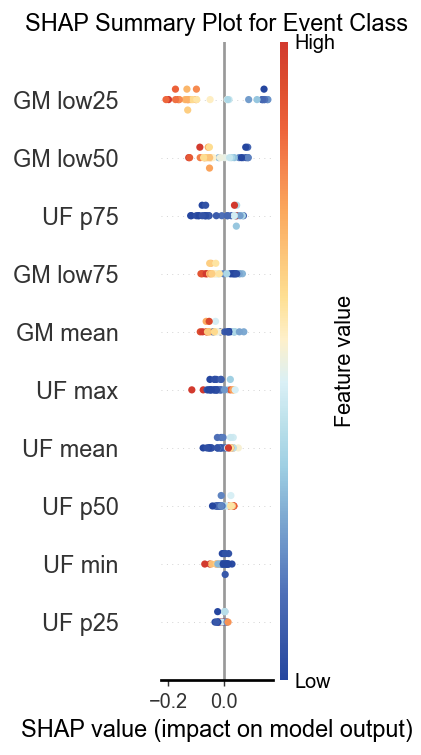

In [11]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_check)

if isinstance(shap_values, list):
    shap_values_event = shap_values[1]
elif getattr(shap_values, "ndim", 0) == 3:
    shap_values_event = shap_values[:, :, 1]
else:
    shap_values_event = shap_values

plt.figure(figsize=(3, 6))
shap.summary_plot(shap_values_event, X_check, show=False, plot_size=None, cmap=CUSTOM_CMAP)
plt.title("SHAP Summary Plot for Event Class")
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
